# Feature Importance Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

In [2]:
rf_model = joblib.load("../models/random_forest.pkl")

print("Random Forest model loaded successfully.")

Random Forest model loaded successfully.


In [3]:
X_test = pd.read_csv("../data/processed/X_test.csv")

print("X_test shape:", X_test.shape)

X_test shape: (504160, 78)


In [4]:
feature_importance = rf_model.feature_importances_

print(feature_importance)

[1.53948242e-02 7.13483910e-03 1.56097593e-02 7.20841346e-03
 3.06056068e-02 3.36732995e-02 3.10800500e-02 1.66509256e-03
 1.80627601e-02 1.34747150e-02 4.22980540e-02 5.10806586e-03
 2.03436948e-02 4.35503907e-02 1.15716634e-02 4.00757232e-03
 1.22914998e-02 1.41846879e-02 5.77325446e-03 3.57728189e-03
 5.77539255e-03 9.65581864e-03 1.26676555e-02 1.51837879e-02
 1.03167683e-02 1.62587876e-03 2.55713193e-03 2.53459281e-03
 1.49738702e-03 1.80462994e-03 4.53050664e-04 0.00000000e+00
 1.53261323e-06 0.00000000e+00 1.52741827e-02 1.36561258e-02
 3.64627547e-03 5.76070975e-03 6.09259894e-03 4.92807635e-02
 1.90190297e-02 6.76135394e-02 6.16960914e-02 2.05378385e-03
 5.08381757e-04 0.00000000e+00 1.38633867e-02 9.82460017e-03
 1.47701247e-03 2.13617987e-06 0.00000000e+00 9.97701700e-04
 4.01549039e-02 2.13036734e-02 6.14390072e-02 1.57335102e-02
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 2.19977718e-02 3.59361582e-02
 1.05408333e-02 2.798561

In [5]:
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": feature_importance
})

importance_df.head()

,Feature,Importance
0,Destination Port,0.015395
1,Flow Duration,0.007135
2,Total Fwd Packets,0.015610
3,Total Backward Packets,0.007208
4,Total Length of Fwd Packets,0.030606


In [6]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
41,Packet Length Std,0.067614
42,Packet Length Variance,0.061696
54,Avg Bwd Segment Size,0.061439
39,Max Packet Length,0.049281
13,Bwd Packet Length Std,0.043550
10,Bwd Packet Length Max,0.042298
52,Average Packet Size,0.040155
63,Subflow Fwd Bytes,0.035936
5,Total Length of Bwd Packets,0.033673
6,Fwd Packet Length Max,0.031080


In [7]:
importance_df.to_csv(
    "../results/feature_importance.csv",
    index=False
)

print("Feature importance table saved successfully.")

Feature importance table saved successfully.


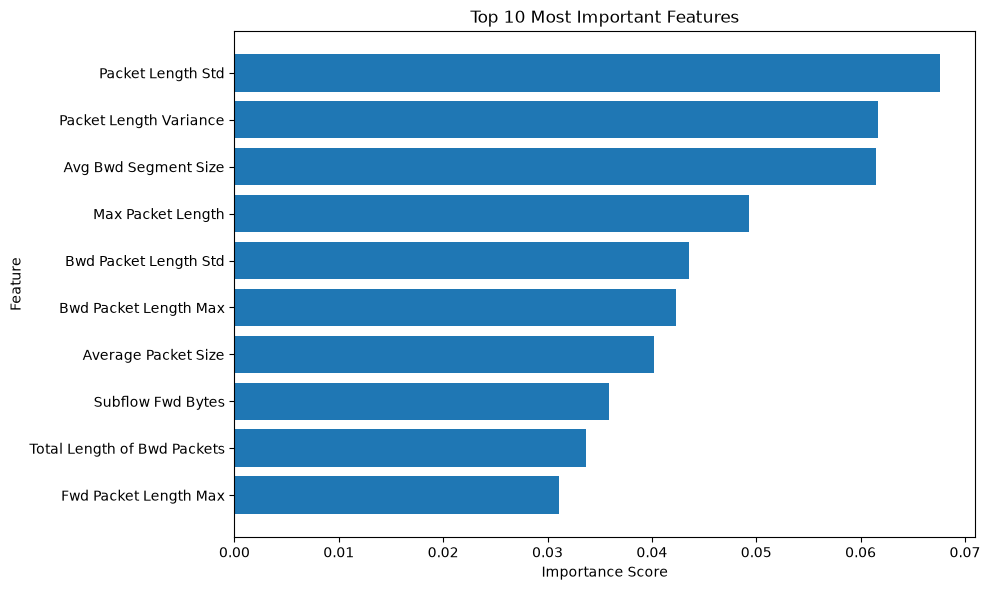

In [8]:
top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

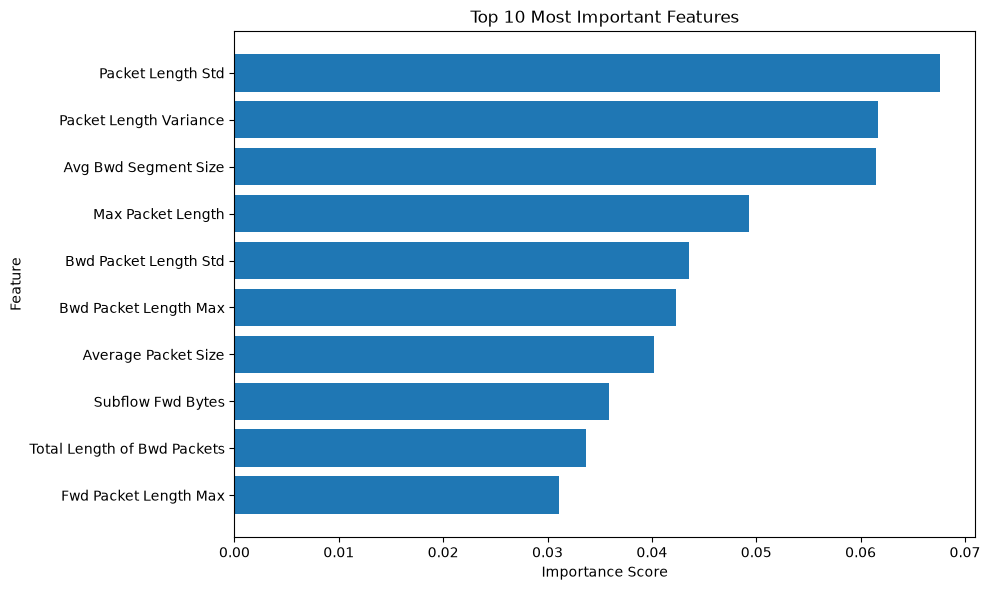

Feature importance chart saved successfully.


In [9]:
plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../results/top_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Feature importance chart saved successfully.")

In [10]:
print("Top 10 Most Important Features:")

top_features.reset_index(drop=True)

Top 10 Most Important Features:


,Feature,Importance
0,Packet Length Std,0.067614
1,Packet Length Variance,0.061696
2,Avg Bwd Segment Size,0.061439
3,Max Packet Length,0.049281
4,Bwd Packet Length Std,0.043550
5,Bwd Packet Length Max,0.042298
6,Average Packet Size,0.040155
7,Subflow Fwd Bytes,0.035936
8,Total Length of Bwd Packets,0.033673
9,Fwd Packet Length Max,0.031080
